In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("vinayakshanawad/meat-freshness-image-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 59.4M/59.4M [00:00<00:00, 152MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vinayakshanawad/meat-freshness-image-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/vinayakshanawad/meat-freshness-image-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/vinayakshanawad/meat-freshness-image-dataset/versions/1):
['Meat Freshness.v1-new-dataset.multiclass']


In [ ]:
import os

# Update path based on cell 1 results
data_path = os.path.join(path, 'Meat Freshness.v1-new-dataset.multiclass')

# List class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Data classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Data classes found: ['valid', 'train']



--- Displaying sample images from dataset (/root/.cache/kagglehub/datasets/vinayakshanawad/meat-freshness-image-dataset/versions/1/Meat Freshness.v1-new-dataset.multiclass) ---
Found 2266 images. Displaying 6 sample images:


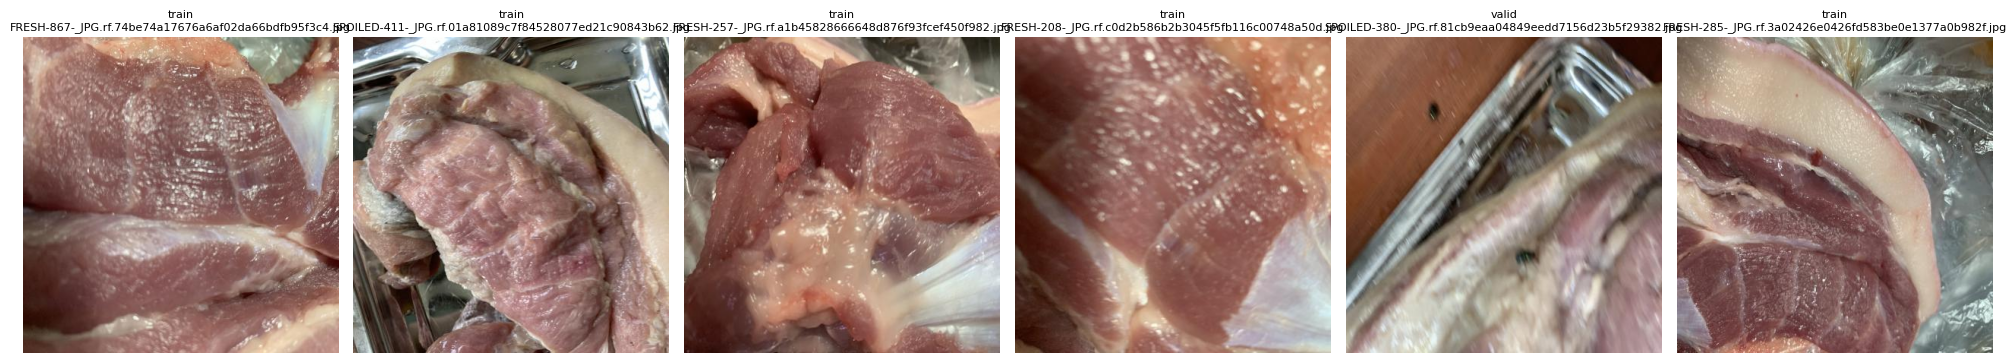

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use updated path
data_path = os.path.join(path, 'Meat Freshness.v1-new-dataset.multiclass')
print(f"\n--- Displaying sample images from dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import tensorflow as tf

# Check GPU availability
print("TensorFlow version:", tf.__version__)
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Training will proceed on CPU.')
else:
  print('Found GPU at: {}'.format(device_name))

# Configure GPU memory growth to prevent allocation errors
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
  except RuntimeError as e:
    print(e)

TensorFlow version: 2.20.0
GPU device not found. Training will proceed on CPU.


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_dataset_from_filenames(directory):
    file_paths = []
    labels = []

    # Map filename prefixes to indices
    class_map = {'FRESH': 0, 'HALF-FRESH': 1, 'SPOILED': 2}

    for filename in os.listdir(directory):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            path = os.path.join(directory, filename)
            file_paths.append(path)

            # Simple label extraction based on the prefix of the filename
            if 'HALF-FRESH' in filename.upper():
                labels.append(1)
            elif 'FRESH' in filename.upper():
                labels.append(0)
            else:
                labels.append(2)

    # Create a TF dataset
    path_ds = tf.data.Dataset.from_tensor_slices(file_paths)
    label_ds = tf.data.Dataset.from_tensor_slices(tf.one_hot(labels, depth=len(class_map)))

    def process_path(file_path, label):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = img / 255.0
        return img, label

    ds = tf.data.Dataset.zip((path_ds, label_ds))
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE), len(class_map)

try:
    train_ds, num_classes = load_dataset_from_filenames(train_dir)
    valid_ds, _ = load_dataset_from_filenames(valid_dir)

    # Build MobileNetV2 model
    with tf.device('/GPU:0' if tf.test.gpu_device_name() else '/CPU:0'):
        base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
        base_model.trainable = False

        model = models.Sequential([
            base_model,
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation='softmax')
        ])

        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.summary()

    print('\nStarting training...')
    history = model.fit(
        train_ds,
        epochs=10,
        validation_data=valid_ds
    )
except Exception as e:
    print(f"Error during custom dataset loading or model setup: {e}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Starting training...
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7675 - loss: 0.5423 - val_accuracy: 0.9180 - val_loss: 0.2150
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8986 - loss: 0.2369 - val_accuracy: 0.9268 - val_loss: 0.1825
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9372 - loss: 0.1655 - val_accuracy: 0.9224 - val_loss: 0.1868
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9603 - loss: 0.1113 - val_accuracy: 0.9379 - val_loss: 0.1548
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9680 - loss: 0.0916 - val_accuracy: 0.9490 - val_loss: 0.1305
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9802 - loss: 0.0632 - val_accuracy: 0.9845 - val_loss: 0.0599
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9884 - loss: 0.0459 - val_accuracy: 0.9823 - val_loss: 0.0531
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9873 - loss: 0.0401 - val_accura

In [ ]:
# Final Evaluation and Summary
if 'model' in locals() and 'valid_ds' in locals():
    loss, accuracy = model.evaluate(valid_ds)
    print(f"\n--- Training Summary ---")
    print(f"Final Validation Loss: {loss:.4f}")
    print(f"Final Validation Accuracy: {accuracy*100:.2f}%")

    # Display class mapping
    class_map = {'FRESH': 0, 'HALF-FRESH': 1, 'SPOILED': 2}
    print(f"Class indices mapping: {class_map}")
else:
    print("Model or validation dataset not available.")

15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 823ms/step - accuracy: 0.9845 - loss: 0.0425

--- Training Summary ---
Final Validation Loss: 0.0425
Final Validation Accuracy: 98.45%
Class indices mapping: {'FRESH': 0, 'HALF-FRESH': 1, 'SPOILED': 2}


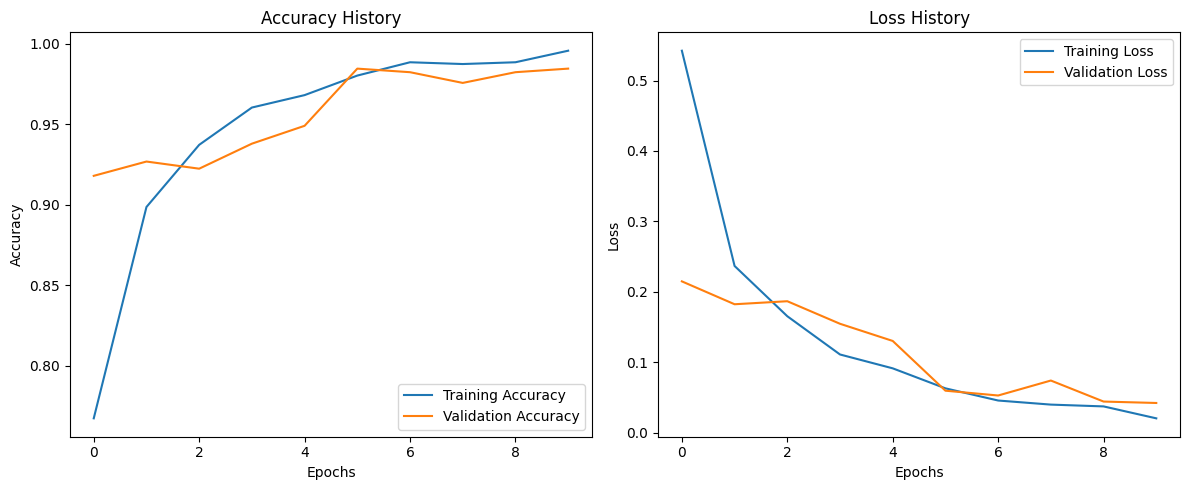

In [ ]:
import matplotlib.pyplot as plt

# Visualize Training History
if 'history' in locals() and hasattr(history, 'history'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy History')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss History')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()
else:
    print("Training history not available. Please ensure the training cell has finished executing.")